In [2]:
from pathlib import Path
import shutil

src_dir = Path(r"E:\with_adapt")
dst_dir = Path(r"C:\修論研究\Iizumi\wheat")
dst_dir.mkdir(parents=True, exist_ok=True)

copied = 0
for f in src_dir.rglob("*"):
    if f.is_file() and f.suffix.lower() == ".nc" and "wheat" in f.name.lower():
        shutil.copy2(f, dst_dir / f.name)
        copied += 1

print(f"コピー完了: {copied} 件")


コピー完了: 150 件


In [3]:
import sys
print(sys.executable)  # どのPythonを使っているか確認
!{sys.executable} -m pip install xarray netCDF4 h5netcdf


c:\Users\tsuda\AppData\Local\Programs\Python\Python313\python.exe
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   ------- -------------------------------- 0.3/1.4 MB ? eta -:--:--
   -------------- ------------------------- 0.5/1.4 MB 308.8 kB/s eta 0:00:03
   -------------- ------------------------- 0.5/1.4 MB 308.8 kB/s eta 0:00:03
   -------------- ------------------------- 0.5/1.4 MB 308.8 kB/s eta 0:00:03
   ---------------------- ----------------- 0.8/1.4 MB 327.7 kB/s eta 0:00:02
   ---------------------- ----------------- 0.8/1.4 MB 327.7 kB/s eta 0:00:02
   ---------------------- ----------------- 0.8/1.4 MB 327.7 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import sys
!{sys.executable} -m pip install -U xarray h5netcdf h5py netCDF4


   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.2 MB ? eta -:--:--
   --- ---------------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path
import tempfile
import shutil
import uuid
from netCDF4 import Dataset

src = Path(r"C:\修論研究\Iizumi\wheat\cygma_gfdl-esm4_ssp126_ssp1_wheat_irri_yld_1981_2100.nc").resolve()
print("src exists:", src.exists())
print("src:", src)

tmp_nc = Path(tempfile.gettempdir()) / f"{src.stem}_{uuid.uuid4().hex}.nc"
print("tmp:", tmp_nc)

# copy2 ではなく copyfile を使う（メタ情報処理を省いてロック衝突を減らす）
shutil.copyfile(src, tmp_nc)

try:
    with Dataset(str(tmp_nc), mode="r") as nc:
        print("\n=== Data model ===")
        print(nc.data_model)

        print("\n=== Dimensions ===")
        for dname, dim in nc.dimensions.items():
            print(f"{dname}: size={len(dim)}, unlimited={dim.isunlimited()}")

        print("\n=== Variables ===")
        for vname, var in nc.variables.items():
            print(f"{vname}: dims={var.dimensions}, shape={var.shape}, dtype={var.dtype}")

        print("\n=== Global attributes ===")
        for aname in nc.ncattrs():
            print(f"{aname}: {getattr(nc, aname)}")
finally:
    try:
        tmp_nc.unlink(missing_ok=True)
    except Exception:
        pass


src exists: True
src: C:\修論研究\Iizumi\wheat\cygma_gfdl-esm4_ssp126_ssp1_wheat_irri_yld_1981_2100.nc
tmp: C:\Users\tsuda\AppData\Local\Temp\cygma_gfdl-esm4_ssp126_ssp1_wheat_irri_yld_1981_2100_2cace70b2747479da70cf374a3598f56.nc

=== Data model ===
NETCDF4

=== Dimensions ===
lon: size=720, unlimited=False
lat: size=360, unlimited=False
time: size=120, unlimited=False

=== Variables ===
lon: dims=('lon',), shape=(720,), dtype=float64
lat: dims=('lat',), shape=(360,), dtype=float64
time: dims=('time',), shape=(120,), dtype=float64
var: dims=('time', 'lat', 'lon'), shape=(120, 360, 720), dtype=float32

=== Global attributes ===


target_year=2100, time index(0-based)=119, (1-based)=120
raw min (fill含む)   : -999000000.0
raw max (fill含む)   : 11.955375671386719
valid min (欠損除外) : 1.8399221035636515e-10
valid max (欠損除外) : 11.955375671386719
count > 100  : 0
count > 1000 : 0
valid_count  : 33392
nan_count    : 225808


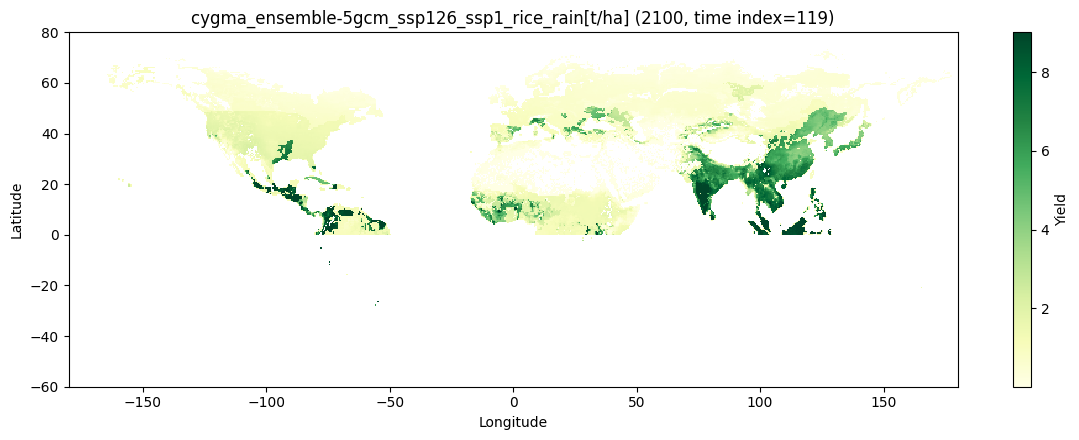

In [20]:
from pathlib import Path
import tempfile
import shutil
import uuid
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset

src = Path(r"C:\修論研究\Iizumi\rice\ensemble_mean_5gcm\cygma_ensemble-5gcm_ssp126_ssp1_rice_rain_yld_1981_2100.nc").resolve()
tmp_nc = Path(tempfile.gettempdir()) / f"{src.stem}_{uuid.uuid4().hex}.nc"
shutil.copyfile(src, tmp_nc)

try:
    with Dataset(str(tmp_nc), mode="r") as nc:
        lon = nc.variables["lon"][:].astype(np.float64)
        lat = nc.variables["lat"][:].astype(np.float64)
        time = nc.variables["time"]
        var = nc.variables["var"]

        # 2010年を time 軸から特定
        # このデータは time.units = "months since 1981-01-01 00:00"
        base_year = int(time.units.split("since")[1].strip().split("-")[0])  # 1981
        target_year = 2100
        target_months = (target_year - base_year) * 12
        ti = int(np.where(np.isclose(time[:], target_months))[0][0])  # 29 (0-based)

        print(f"target_year={target_year}, time index(0-based)={ti}, (1-based)={ti+1}")

        raw = var[ti, :, :]
        raw_np = np.asarray(raw, dtype=np.float64)

        # 欠損値を NaN に統一
        if np.ma.isMaskedArray(raw):
            data = raw.filled(np.nan).astype(np.float64)
        else:
            data = raw_np.copy()
            for attr in ["_FillValue", "missing_value"]:
                fv = getattr(var, attr, None)
                if fv is not None:
                    data[data == float(fv)] = np.nan

        # 統計
        print("raw min (fill含む)   :", np.nanmin(raw_np))
        print("raw max (fill含む)   :", np.nanmax(raw_np))
        print("valid min (欠損除外) :", np.nanmin(data))
        print("valid max (欠損除外) :", np.nanmax(data))

        finite = data[np.isfinite(data)]
        print("count > 100  :", int(np.sum(finite > 100)))
        print("count > 1000 :", int(np.sum(finite > 1000)))
        print("valid_count  :", finite.size)
        print("nan_count    :", int(np.isnan(data).sum()))

        # 0..360 -> -180..180 に並べ替えて地図っぽく表示
        lon_wrap = ((lon + 180.0) % 360.0) - 180.0
        order = np.argsort(lon_wrap)
        lon_plot = lon_wrap[order]
        data_plot = data[:, order]

        # 色スケールは外れ値の影響を抑える
        vmin, vmax = np.nanpercentile(data_plot, [2, 98])

        fig, ax = plt.subplots(figsize=(12, 4.5))
        im = ax.pcolormesh(
            lon_plot, lat, data_plot,
            shading="auto", cmap="YlGn", vmin=vmin, vmax=vmax
        )
        ax.set_xlim(-180, 180)
        ax.set_ylim(-60, 80)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(f"cygma_ensemble-5gcm_ssp126_ssp1_rice_rain[t/ha] ({target_year}, time index={ti})")
        fig.colorbar(im, ax=ax, label="Yield")
        fig.tight_layout()

        
        plt.show()

finally:
    tmp_nc.unlink(missing_ok=True)


# 排出シナリオー社会経済シナリオをそろえたうえで、それぞれについて気候モデルに関してensembleをとる

In [ ]:
#!/usr/bin/env python3
from __future__ import annotations

import argparse
import re
import shutil
import tempfile
import uuid
from collections import defaultdict
from contextlib import ExitStack
from datetime import datetime, timezone
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
from netCDF4 import Dataset


FILENAME_RE = re.compile(
    r"^cygma_"
    r"(?P<model>[^_]+)_"
    r"(?P<rcp>[^_]+)_"
    r"(?P<ssp>[^_]+)_"
    r"(?P<crop>[^_]+)_"
    r"(?P<system>[^_]+)_"
    r"(?P<variable>[^_]+)_"
    r"(?P<period_start>\d{4})_"
    r"(?P<period_end>\d{4})"
    r"\.nc$"
)


EXPECTED_MODELS = [
    "gfdl-esm4",
    "ipsl-cm6a-lr",
    "mri-esm2-0",
    "mpi-esm1-2-hr",
    "ukesm1-0-ll",
]


KeyType = Tuple[str, str, str, str, str, str, str]


def parse_args() -> argparse.Namespace:
    default_input = Path.cwd().parent / "Iizumi" / "wheat"
    parser = argparse.ArgumentParser(
        description=(
            "Build multi-GCM ensemble mean NetCDF files for wheat data. "
            "If any model is missing at a grid/time point, output is set to fill value."
        )
    )
    parser.add_argument(
        "--input-dir",
        type=Path,
        default=default_input,
        help="Directory that contains cygma_*.nc files (default: ../Iizumi/wheat).",
    )
    parser.add_argument(
        "--output-subdir",
        type=str,
        default="ensemble_mean_5gcm",
        help="Subdirectory (created under input-dir) for generated files.",
    )
    parser.add_argument(
        "--ensemble-model-name",
        type=str,
        default="ensemble-5gcm",
        help="Token used in output filename at climate-model position.",
    )
    return parser.parse_args()


def group_files(input_dir: Path) -> Dict[KeyType, Dict[str, Path]]:
    groups: Dict[KeyType, Dict[str, Path]] = defaultdict(dict)
    files = sorted(input_dir.glob("cygma_*.nc"))
    if not files:
        raise FileNotFoundError(f"No cygma_*.nc files found in: {input_dir}")

    for f in files:
        m = FILENAME_RE.match(f.name)
        if not m:
            continue
        model = m.group("model")
        key: KeyType = (
            m.group("rcp"),
            m.group("ssp"),
            m.group("crop"),
            m.group("system"),
            m.group("variable"),
            m.group("period_start"),
            m.group("period_end"),
        )
        groups[key][model] = f

    return groups


def assert_group_integrity(groups: Dict[KeyType, Dict[str, Path]]) -> None:
    if not groups:
        raise RuntimeError("No valid groups parsed from file names.")

    expected = set(EXPECTED_MODELS)
    errors: List[str] = []
    for key, model_map in sorted(groups.items()):
        models = set(model_map.keys())
        missing = sorted(expected - models)
        extra = sorted(models - expected)
        if missing or extra:
            errors.append(
                f"key={key} missing={missing if missing else '-'} extra={extra if extra else '-'}"
            )
    if errors:
        preview = "\n".join(errors[:10])
        raise RuntimeError(
            "Model set mismatch found in grouped files.\n"
            f"{preview}\n(total mismatch groups: {len(errors)})"
        )


def _sentinel_values(var) -> List[float]:
    vals: List[float] = []
    for attr in ("_FillValue", "missing_value"):
        if hasattr(var, attr):
            val = getattr(var, attr)
            try:
                vals.append(float(np.array(val).item()))
            except Exception:
                pass
    return vals


def _any_missing(arr, sentinels: List[float]) -> np.ndarray:
    if np.ma.isMaskedArray(arr):
        mask = np.ma.getmaskarray(arr).copy()
        values = np.asarray(arr, dtype=np.float64)
    else:
        values = np.asarray(arr, dtype=np.float64)
        mask = np.zeros(values.shape, dtype=bool)
    for s in sentinels:
        mask |= np.isclose(values, s, rtol=0.0, atol=0.0)
    return mask


def _extract_values(arr) -> np.ndarray:
    if np.ma.isMaskedArray(arr):
        return np.asarray(arr.data, dtype=np.float64)
    return np.asarray(arr, dtype=np.float64)


def _copy_coord_var(src_ds: Dataset, dst_ds: Dataset, name: str) -> None:
    src_var = src_ds.variables[name]
    dst_var = dst_ds.createVariable(name, src_var.dtype, src_var.dimensions)
    dst_var[:] = src_var[:]
    for attr in src_var.ncattrs():
        dst_var.setncattr(attr, src_var.getncattr(attr))


def _validate_alignment(template_ds: Dataset, candidate_ds: Dataset, path: Path) -> None:
    for dim_name in ("time", "lat", "lon"):
        if dim_name not in candidate_ds.dimensions:
            raise RuntimeError(f"{path.name}: missing dimension '{dim_name}'")
        if len(template_ds.dimensions[dim_name]) != len(candidate_ds.dimensions[dim_name]):
            raise RuntimeError(f"{path.name}: dimension length mismatch in '{dim_name}'")
    for var_name in ("time", "lat", "lon", "var"):
        if var_name not in candidate_ds.variables:
            raise RuntimeError(f"{path.name}: missing variable '{var_name}'")
    for coord in ("time", "lat", "lon"):
        a = np.asarray(template_ds.variables[coord][:], dtype=np.float64)
        b = np.asarray(candidate_ds.variables[coord][:], dtype=np.float64)
        if not np.allclose(a, b, rtol=0.0, atol=0.0):
            raise RuntimeError(f"{path.name}: coordinate mismatch in '{coord}'")
    if template_ds.variables["var"].dimensions != candidate_ds.variables["var"].dimensions:
        raise RuntimeError(f"{path.name}: var dimension order mismatch")


def write_ensemble_file(
    model_paths: Dict[str, Path],
    output_path: Path,
    ensemble_model_name: str,
    key: KeyType,
) -> None:
    rcp, ssp, crop, system, variable, period_start, period_end = key
    ordered_paths = [model_paths[m] for m in EXPECTED_MODELS]

    # netCDF4 in this environment cannot directly open Japanese path strings.
    # Workaround: copy input files and output file through an ASCII temp directory.
    temp_root = Path(tempfile.gettempdir()) / f"wheat_ens_{uuid.uuid4().hex}"
    temp_root.mkdir(parents=True, exist_ok=True)
    temp_in_paths: List[Path] = []
    temp_out_path = temp_root / "out.nc"

    try:
        for i, p in enumerate(ordered_paths):
            tmp_p = temp_root / f"in_{i}.nc"
            shutil.copyfile(p, tmp_p)
            temp_in_paths.append(tmp_p)

        with ExitStack() as stack:
            src_datasets = [stack.enter_context(Dataset(str(p), mode="r")) for p in temp_in_paths]
            template_ds = src_datasets[0]
            for ds, p in zip(src_datasets[1:], ordered_paths[1:]):
                _validate_alignment(template_ds, ds, p)

            with Dataset(str(temp_out_path), mode="w", format="NETCDF4") as out_ds:
                for dim_name in ("lon", "lat", "time"):
                    dim = template_ds.dimensions[dim_name]
                    out_ds.createDimension(dim_name, None if dim.isunlimited() else len(dim))

                _copy_coord_var(template_ds, out_ds, "lon")
                _copy_coord_var(template_ds, out_ds, "lat")
                _copy_coord_var(template_ds, out_ds, "time")

                src_var0 = template_ds.variables["var"]
                out_fill = float(getattr(src_var0, "_FillValue", -999000000.0))
                out_var = out_ds.createVariable(
                    "var",
                    src_var0.dtype,
                    src_var0.dimensions,
                    fill_value=out_fill,
                    zlib=True,
                    complevel=1,
                )
                for attr in src_var0.ncattrs():
                    if attr == "_FillValue":
                        continue
                    out_var.setncattr(attr, src_var0.getncattr(attr))

                for attr in template_ds.ncattrs():
                    out_ds.setncattr(attr, template_ds.getncattr(attr))
                created_at = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
                history_msg = (
                    f"{created_at} created by ensemble averaging models={','.join(EXPECTED_MODELS)}; "
                    f"missing rule=any-missing->fill; ensemble_model_name={ensemble_model_name}"
                )
                if "history" in out_ds.ncattrs():
                    prev = str(out_ds.getncattr("history"))
                    out_ds.setncattr("history", f"{history_msg}\n{prev}")
                else:
                    out_ds.setncattr("history", history_msg)

                time_len = len(template_ds.dimensions["time"])
                sentinels_each = [_sentinel_values(ds.variables["var"]) for ds in src_datasets]
                for t in range(time_len):
                    arrs = [ds.variables["var"][t, :, :] for ds in src_datasets]
                    missing_mask = np.zeros(arrs[0].shape, dtype=bool)
                    vals: List[np.ndarray] = []
                    for arr, sentinels in zip(arrs, sentinels_each):
                        missing_mask |= _any_missing(arr, sentinels)
                        vals.append(_extract_values(arr))
                    stacked = np.stack(vals, axis=0)
                    mean_vals = np.mean(stacked, axis=0, dtype=np.float64)
                    mean_vals[missing_mask] = out_fill
                    out_var[t, :, :] = mean_vals.astype(np.float32)

        output_path.parent.mkdir(parents=True, exist_ok=True)
        shutil.copyfile(temp_out_path, output_path)
    finally:
        shutil.rmtree(temp_root, ignore_errors=True)

    print(f"[OK] {output_path.name}")
    print(
        "     key="
        f"{rcp}_{ssp}_{crop}_{system}_{variable}_{period_start}_{period_end}"
    )


def main() -> None:
    args = parse_args()
    input_dir = args.input_dir.resolve()
    output_dir = (input_dir / args.output_subdir).resolve()

    if not input_dir.exists():
        raise FileNotFoundError(f"Input directory not found: {input_dir}")

    groups = group_files(input_dir)
    assert_group_integrity(groups)

    print(f"input_dir: {input_dir}")
    print(f"output_dir: {output_dir}")
    print(f"group_count: {len(groups)}")
    print(f"models: {EXPECTED_MODELS}")

    for key in sorted(groups.keys()):
        rcp, ssp, crop, system, variable, period_start, period_end = key
        out_name = (
            f"cygma_{args.ensemble_model_name}_{rcp}_{ssp}_{crop}_{system}_"
            f"{variable}_{period_start}_{period_end}.nc"
        )
        out_path = output_dir / out_name
        write_ensemble_file(
            model_paths=groups[key],
            output_path=out_path,
            ensemble_model_name=args.ensemble_model_name,
            key=key,
        )

    print(f"Completed. Created {len(groups)} ensemble files in: {output_dir}")


if __name__ == "__main__":
    main()


# シナリオごとに、単位収量の変化アニメーションをつくる

In [ ]:
#!/usr/bin/env python3
from __future__ import annotations

import argparse
import shutil
import tempfile
import uuid
from pathlib import Path
from typing import Iterable, List, Tuple

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
import numpy as np
from netCDF4 import Dataset


COMBOS: List[Tuple[str, str]] = [
    ("ssp126", "ssp1"),
    ("ssp370", "ssp3"),
    ("ssp585", "ssp3"),
]
SYSTEMS = ["irri", "rain"]
CROPS = ["rice", "wheat"]


def parse_args() -> argparse.Namespace:
    default_root = Path.cwd().parent / "Iizumi"
    parser = argparse.ArgumentParser(
        description=(
            "Create time-series GIF animations from ensemble mean NetCDF files "
            "for selected scenarios and systems."
        )
    )
    parser.add_argument(
        "--root",
        type=Path,
        default=default_root,
        help="Root directory that contains rice/ and wheat/ (default: ../Iizumi).",
    )
    parser.add_argument(
        "--ensemble-subdir",
        type=str,
        default="ensemble_mean_5gcm",
        help="Subdirectory name where ensemble files are stored.",
    )
    parser.add_argument(
        "--output-subdir",
        type=str,
        default="animations_ensemble_mean_5gcm",
        help="Subdirectory name created under each crop directory for GIF outputs.",
    )
    parser.add_argument(
        "--fps",
        type=int,
        default=6,
        help="Frames per second for GIF.",
    )
    parser.add_argument(
        "--dpi",
        type=int,
        default=120,
        help="DPI for saved GIF frames.",
    )
    return parser.parse_args()


def _copy_to_temp(src: Path, temp_dir: Path, name: str) -> Path:
    dst = temp_dir / name
    shutil.copyfile(src, dst)
    return dst


def _to_data_and_mask(var_t, var_obj) -> Tuple[np.ndarray, np.ndarray]:
    if np.ma.isMaskedArray(var_t):
        data = np.asarray(var_t.data, dtype=np.float64)
        missing = np.ma.getmaskarray(var_t).copy()
    else:
        data = np.asarray(var_t, dtype=np.float64)
        missing = np.zeros(data.shape, dtype=bool)

    for attr in ("_FillValue", "missing_value"):
        if hasattr(var_obj, attr):
            fv = float(np.array(getattr(var_obj, attr)).item())
            missing |= np.isclose(data, fv, rtol=0.0, atol=0.0)
    return data, missing


def _years_from_time(time_var) -> np.ndarray:
    units = str(getattr(time_var, "units", ""))
    if "since" in units:
        # Expected pattern: "months since YYYY-MM-DD ..."
        after = units.split("since", 1)[1].strip()
        base_year = int(after.split("-", 1)[0])
    else:
        base_year = 1981
    tvals = np.asarray(time_var[:], dtype=np.float64)
    years = base_year + np.rint(tvals / 12.0).astype(int)
    return years


def build_animation(input_nc: Path, output_gif: Path, fps: int, dpi: int) -> None:
    temp_root = Path(tempfile.gettempdir()) / f"anim_{uuid.uuid4().hex}"
    temp_root.mkdir(parents=True, exist_ok=True)
    try:
        temp_nc = _copy_to_temp(input_nc, temp_root, "in.nc")
        with Dataset(str(temp_nc), "r") as nc:
            lat = np.asarray(nc.variables["lat"][:], dtype=np.float64)
            lon = np.asarray(nc.variables["lon"][:], dtype=np.float64)
            var = nc.variables["var"]
            years = _years_from_time(nc.variables["time"])
            n_time = len(nc.dimensions["time"])

            # 0..360 -> -180..180 ordering for map-like display.
            lon_wrap = ((lon + 180.0) % 360.0) - 180.0
            order = np.argsort(lon_wrap)
            lon_plot = lon_wrap[order]

            # Get robust color limits from all valid cells in this file.
            all_vals = []
            for t in range(n_time):
                d, m = _to_data_and_mask(var[t, :, :], var)
                d = d.copy()
                d[m] = np.nan
                valid = d[np.isfinite(d)]
                if valid.size:
                    all_vals.append(valid)
            if not all_vals:
                raise RuntimeError(f"No valid values found in {input_nc.name}")
            cat = np.concatenate(all_vals)
            vmin = float(np.nanpercentile(cat, 2))
            vmax = float(np.nanpercentile(cat, 98))
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
                vmin = float(np.nanmin(cat))
                vmax = float(np.nanmax(cat))

            fig, ax = plt.subplots(figsize=(12, 4.8))
            fig.patch.set_facecolor("white")
            ax.set_facecolor("#f0f0f0")

            d0, m0 = _to_data_and_mask(var[0, :, :], var)
            d0 = d0[:, order].copy()
            m0 = m0[:, order]
            d0[m0] = np.nan
            mesh = ax.pcolormesh(
                lon_plot,
                lat,
                d0,
                shading="auto",
                cmap="YlGn",
                vmin=vmin,
                vmax=vmax,
            )
            ax.set_xlim(-180, 180)
            ax.set_ylim(-60, 80)
            ax.set_xlabel("Longitude")
            ax.set_ylabel("Latitude")
            title = ax.set_title(f"{input_nc.stem} (year={years[0]}, time index=0)")
            cbar = fig.colorbar(mesh, ax=ax, label="Yield")
            cbar.ax.tick_params(labelsize=9)
            fig.tight_layout()

            # pcolormesh update expects flattened array.
            ny, nx = d0.shape

            def update(frame: int):
                d, m = _to_data_and_mask(var[frame, :, :], var)
                d = d[:, order].copy()
                m = m[:, order]
                d[m] = np.nan
                mesh.set_array(d.ravel())
                title.set_text(f"{input_nc.stem} (year={years[frame]}, time index={frame})")
                return (mesh, title)

            anim = FuncAnimation(
                fig,
                update,
                frames=n_time,
                interval=max(1, int(1000 / fps)),
                blit=False,
            )

            output_gif.parent.mkdir(parents=True, exist_ok=True)
            writer = PillowWriter(fps=fps)
            anim.save(str(output_gif), writer=writer, dpi=dpi)
            plt.close(fig)
            print(f"[OK] {output_gif}")
    finally:
        shutil.rmtree(temp_root, ignore_errors=True)


def iter_targets(root: Path, ensemble_subdir: str) -> Iterable[Tuple[Path, Path]]:
    for crop in CROPS:
        src_dir = root / crop / ensemble_subdir
        for rcp, ssp in COMBOS:
            for sys in SYSTEMS:
                in_name = f"cygma_ensemble-5gcm_{rcp}_{ssp}_{crop}_{sys}_yld_1981_2100.nc"
                yield src_dir / in_name, root / crop


def main() -> None:
    args = parse_args()
    root = args.root.resolve()

    targets = list(iter_targets(root, args.ensemble_subdir))
    missing = [p for p, _ in targets if not p.exists()]
    if missing:
        raise FileNotFoundError(
            "Missing input files:\n" + "\n".join(str(p) for p in missing)
        )

    print(f"root: {root}")
    print(f"target_count: {len(targets)}")
    for input_nc, crop_dir in targets:
        out_dir = crop_dir / args.output_subdir
        out_name = input_nc.stem + ".gif"
        out_gif = out_dir / out_name
        build_animation(input_nc=input_nc, output_gif=out_gif, fps=args.fps, dpi=args.dpi)

    print("Completed all animations.")


if __name__ == "__main__":
    main()
